In [39]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [41]:
df = pd.read_csv("../data/churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [42]:
df.shape

(7043, 21)

In [43]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [45]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

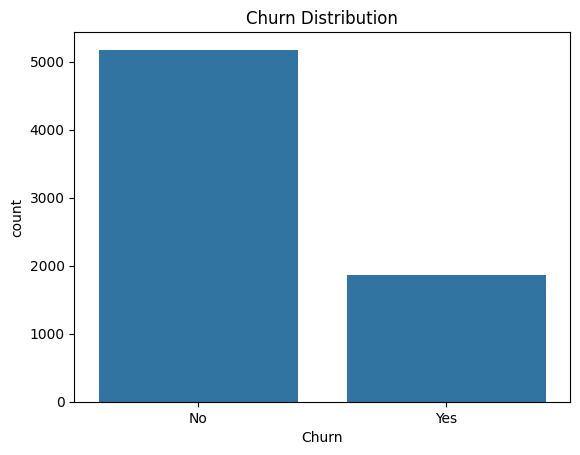

In [46]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [47]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [48]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [49]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [50]:
df = df.drop("customerID", axis=1)

In [51]:
df["AvgMonthlySpend"] = df["TotalCharges"] / df["tenure"].replace(0,1)

In [52]:
df["IsMonthToMonth"] = (df["Contract"] == "Month-to-month").astype(int)

In [53]:
services = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = df[services].apply(
    lambda row: sum(row == "Yes"),
    axis=1
)

In [54]:
df.shape

df[[
    "AvgMonthlySpend",
    "IsMonthToMonth",
    "ServiceCount"
]].head()

,AvgMonthlySpend,IsMonthToMonth,ServiceCount
0,29.850000,1,1
1,55.573529,0,3
2,54.075000,1,3
3,40.905556,0,3
4,75.825000,1,1


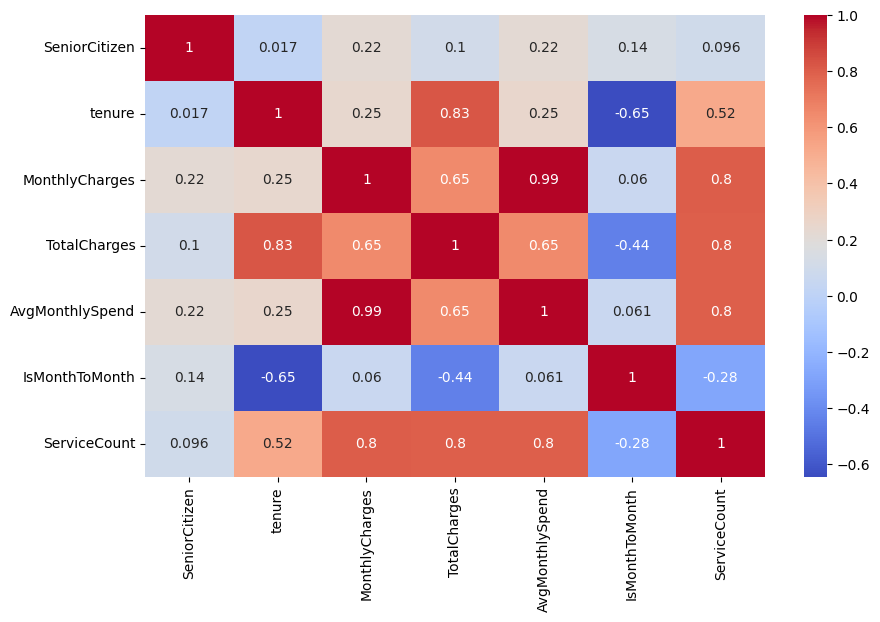

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

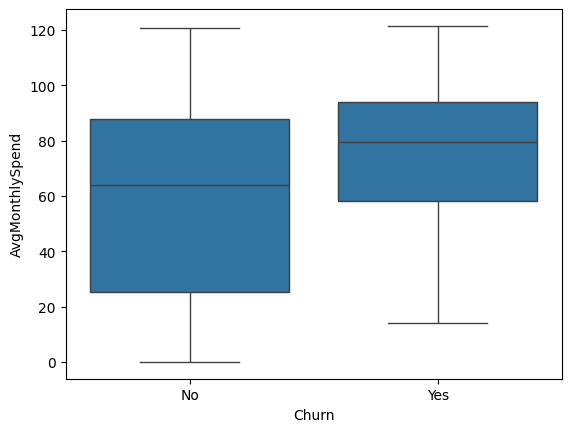

In [56]:
sns.boxplot(x="Churn", y="AvgMonthlySpend", data=df)
plt.show()

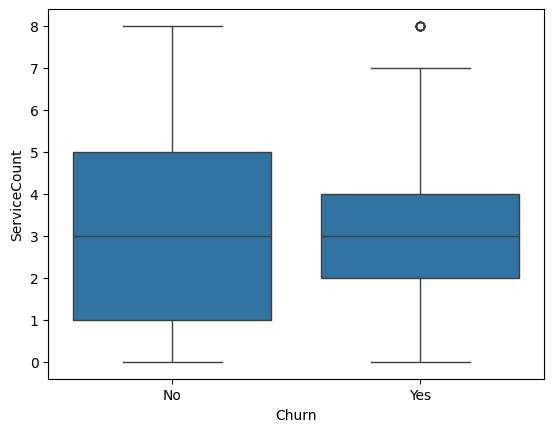

In [57]:
sns.boxplot(x="Churn", y="ServiceCount", data=df)
plt.show()

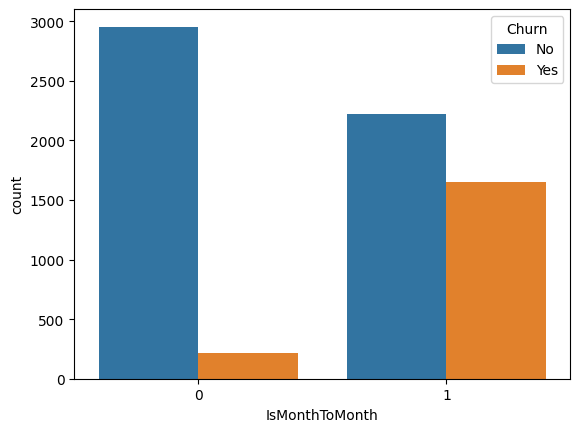

In [58]:
sns.countplot(x="IsMonthToMonth", hue="Churn", data=df)
plt.show()

In [59]:
df = df.drop(["AvgMonthlySpend", "ServiceCount"], axis=1)

In [60]:
y = df["Churn"].map({"Yes":1, "No":0})

X = df.drop(["Churn", "Churn_binary"], axis=1, errors="ignore")

In [61]:
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

In [62]:
for col in binary_cols:
    X[col] = X[col].map({
        "Yes":1,
        "No":0,
        "Male":1,
        "Female":0
    })

In [63]:
multi_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

In [64]:
X_encoded = pd.get_dummies(
    X,
    columns=multi_cols,
    drop_first=True
)

In [65]:
X_encoded.select_dtypes("object").columns

Index([], dtype='str')

In [66]:
X_encoded.isna().sum().sum()

np.int64(0)

In [67]:
X_encoded.shape

(7043, 31)

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [69]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

c:\Users\senab\anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [71]:
y_prob = log_model.predict_proba(X_test)[:,1]

In [72]:
from sklearn.metrics import classification_report

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    print(f"\nThreshold: {t}")
    
    y_pred_thresh = (y_prob >= t).astype(int)
    
    print(classification_report(y_test, y_pred_thresh))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.96      0.56      0.71      1035
           1       0.43      0.93      0.59       374

    accuracy                           0.66      1409
   macro avg       0.69      0.74      0.65      1409
weighted avg       0.82      0.66      0.67      1409


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.64      0.76      1035
           1       0.47      0.87      0.61       374

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.81      0.70      0.72      1409


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80   

In [73]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [74]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1035
           1       0.54      0.79      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [75]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [76]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    print(f"\nThreshold: {t}")
    y_pred_thresh = (y_prob_rf >= t).astype(int)
    print(classification_report(y_test, y_pred_thresh))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.94      0.58      0.72      1035
           1       0.44      0.90      0.59       374

    accuracy                           0.67      1409
   macro avg       0.69      0.74      0.66      1409
weighted avg       0.81      0.67      0.69      1409


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      0.67      0.78      1035
           1       0.48      0.84      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.81      0.72      0.73      1409


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1035
           1       0.54      0.79      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81   